# Player Similarity - Clustering

This notebook uses K-means clustering to group players according to their goals, assists, shots, fouls drawn, offsides, and crosses per 90.

In [268]:
import pandas as pd

df = pd.read_csv('../data/processed/player_contributions.csv')

forwards_df = df.loc[df['PrimaryPos'].isin(['FW'])].copy()

features = ['Gls90', 'Ast90', 'Sh/90', 'Fld/90', 'Off/90', 'Crs/90']

X = forwards_df[features].copy()

In [269]:
correlation = X.corr().round(2)
correlation

,Gls90,Ast90,Sh/90,Fld/90,Off/90,Crs/90
Gls90,1.00,-0.01,0.57,-0.20,0.07,-0.38
Ast90,-0.01,1.00,0.15,0.30,-0.03,0.25
Sh/90,0.57,0.15,1.00,0.10,0.17,-0.19
Fld/90,-0.20,0.30,0.10,1.00,-0.05,0.30
Off/90,0.07,-0.03,0.17,-0.05,1.00,-0.32
Crs/90,-0.38,0.25,-0.19,0.30,-0.32,1.00


## Feature scaling

Features per 90 mins are standardised before clustering.

In [270]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit(X).transform(X)

## Selecting the number of clusters

Several values of k are evaluated using inertia and silhouette score.

In [271]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2,9)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )


## Visualising results of elbow method and silhouette method

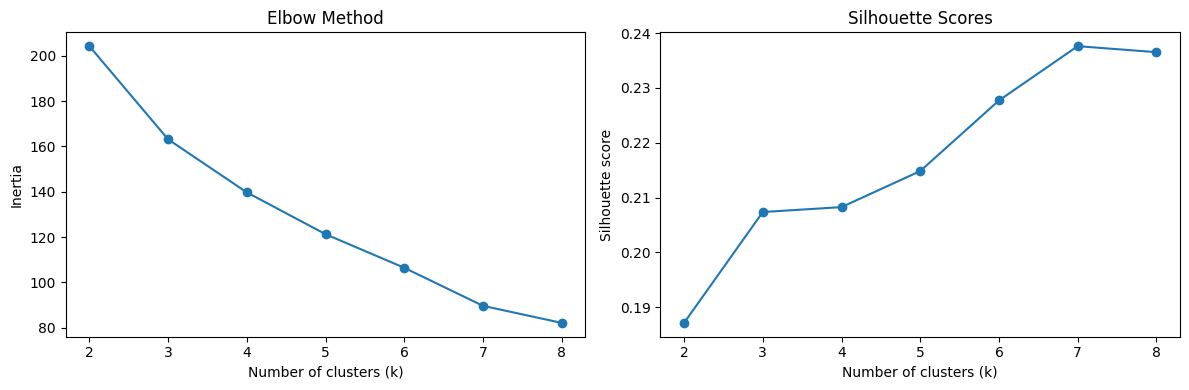

In [272]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_title("Silhouette Scores")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

## Creating final model and plotting it

In [273]:
final_model = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10)

cluster_labels = final_model.fit_predict(X_scaled)
forwards_df['Cluster'] = cluster_labels
# forwards_df[['Player', 'Gls90', 'Ast90', 'Cluster']].sort_values(['Cluster', 'Gls90'], ascending=[True,False])
cluster_averages = (
    forwards_df
    .groupby("Cluster")[features]
    .mean()
    .round(2)
)


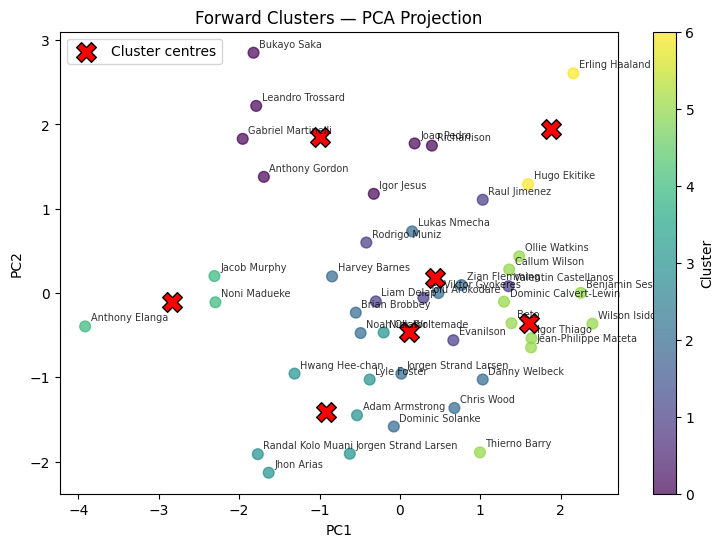

,Gls90,Ast90,Sh/90,Fld/90,Off/90,Crs/90
Cluster,,,,,,
0,0.31,0.20,2.59,1.72,0.41,2.28
1,0.22,0.05,2.89,1.32,0.59,0.27
2,0.41,0.03,2.24,1.05,0.20,0.74
3,0.15,0.09,1.30,0.79,0.43,0.81
4,0.13,0.08,1.79,1.18,0.24,6.17
5,0.50,0.04,2.62,0.74,0.66,0.25
6,0.68,0.22,3.54,0.68,0.32,0.22


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "Cluster": forwards_df["Cluster"].to_numpy(),
        "Player": forwards_df["Player"].to_numpy()
    }
)

centres_pca = pca.transform(
    final_model.cluster_centers_
)

ax = pca_df.plot.scatter(
    x="PC1",
    y="PC2",
    c="Cluster",
    cmap="viridis",
    colorbar=True,
    figsize=(9, 6),
    alpha=0.7,
    s=60,
    title="Forward Clusters — PCA Projection"
)

ax.scatter(
    centres_pca[:, 0],
    centres_pca[:, 1],
    color="red",
    marker="X",
    s=200,
    edgecolors="black",
    label="Cluster centres"
)

for _, player in pca_df.iterrows():
    plt.annotate(
        player["Player"],
        (player["PC1"], player["PC2"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        alpha=0.8
    )

ax.legend()
plt.show()

cluster_averages

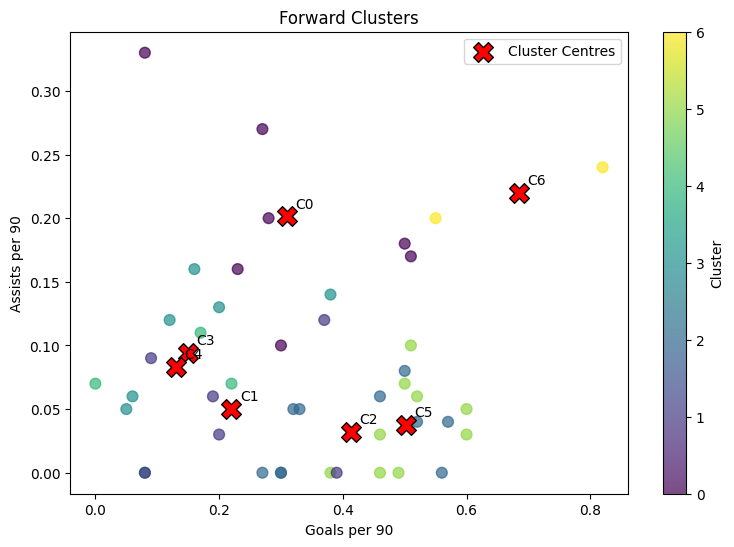

In [275]:
cluster_centres = scaler.inverse_transform(final_model.cluster_centers_)

ax = forwards_df.plot.scatter(
    title='Forward Clusters',
    x='Gls90',
    y='Ast90',
    c='Cluster',
    cmap='viridis',
    colorbar=True,
    figsize=(9, 6),
    alpha=0.7,
    s=60
)

ax.scatter(
    cluster_centres[:, 0],
    cluster_centres[:, 1],
    color='red',
    marker='X',
    s=200,
    edgecolors='black',
    label='Cluster Centres'
    )

for cluster_id, centre in enumerate(cluster_centres):
    ax.annotate(
        f"C{cluster_id}",
        (centre[0], centre[1]),
        xytext=(6, 6),
        textcoords="offset points"
    )

ax.set_xlabel("Goals per 90")
ax.set_ylabel("Assists per 90")
ax.legend()

plt.show()

## Finding similar players

K means provides broad forward profiles but does not rank individual similarity. A nearest neighbour model is applied to the same standardised features. Players with the shortest Euclidean distance are considered the most statistically similar.

In [278]:
from sklearn.neighbors import NearestNeighbors

forwards_lookup = forwards_df.reset_index(drop=True).copy()

forwards_lookup['PlayerLabel'] = (
    forwards_lookup['Player'] + " - " + forwards_lookup['Squad']
)

nearest_model = NearestNeighbors(metric='euclidean')
nearest_model.fit(X_scaled)


def find_similar_players(player_label, number_of_results=5):
    matching_positions = forwards_lookup.index[
        forwards_lookup["PlayerLabel"].eq(player_label)
    ].tolist()

    if not matching_positions:
        raise ValueError(
            f"No forward found with the label: {player_label}"
        )

    if number_of_results < 1:
        raise ValueError(
            "number_of_results must be at least 1"
        )

    query_position = matching_positions[0]

    maximum_results = len(forwards_lookup) - 1
    number_of_results = min(
        number_of_results,
        maximum_results
    )

    distances, positions = nearest_model.kneighbors(
        X_scaled[[query_position]],
        n_neighbors=number_of_results + 1
    )

    neighbour_pairs = [
        (position, distance)
        for position, distance in zip(
            positions[0],
            distances[0]
        )
        if position != query_position
    ][:number_of_results]

    neighbour_positions = [
        position for position, distance in neighbour_pairs
    ]

    neighbour_distances = [
        distance for position, distance in neighbour_pairs
    ]

    # results = forwards_lookup.iloc[neighbour_positions][
    #     [
    #         "PlayerLabel",
    #         "Player",
    #         "Squad",
    #         "Gls90",
    #         "Ast90",
    #         "Cluster"
    #     ]
    # ].copy()

    result_columns = [
    "PlayerLabel",
    *features,
    "Cluster"
    ]

    results = forwards_lookup.iloc[
        neighbour_positions
    ][result_columns].copy()

    results["Distance"] = neighbour_distances

    return results.reset_index(drop=True)


selected_player = "Benjamin Sesko - Manchester Utd"

similar_players = find_similar_players(selected_player, 2)

similar_players



,PlayerLabel,Gls90,Ast90,Sh/90,Fld/90,Off/90,Crs/90,Cluster,Distance
0,Beto - Everton,0.52,0.06,2.47,0.69,0.52,0.11,5,1.715601
1,Danny Welbeck - Brighton,0.52,0.04,2.23,0.40,0.20,0.12,2,1.927364


## Visual validation of similar players

The selected player and their five nearest neighbours are highlighted.

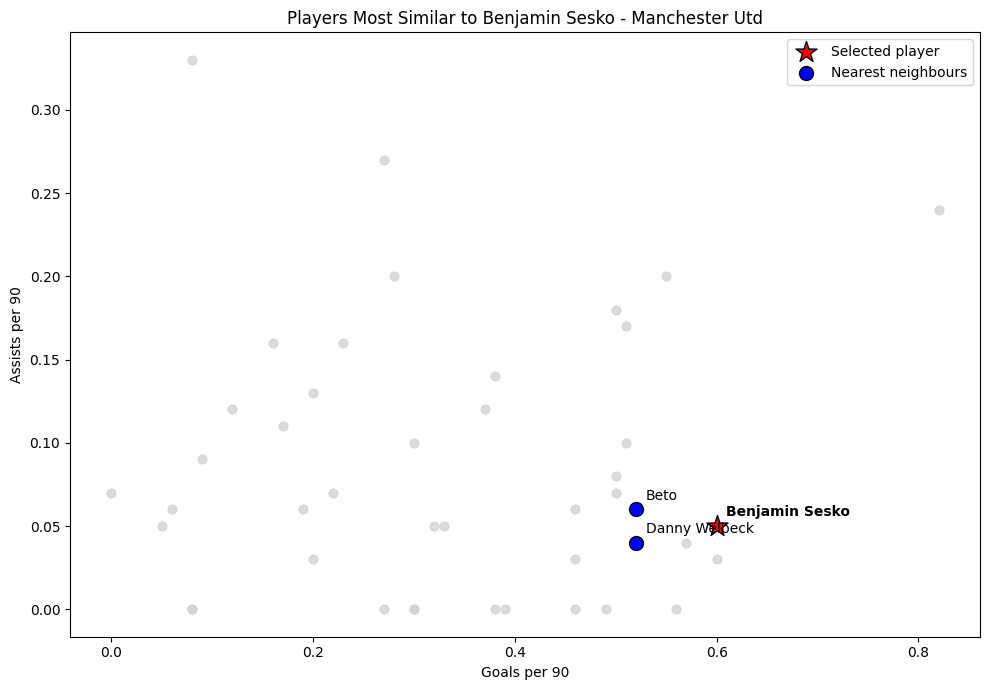

In [277]:
selected_row = forwards_lookup.loc[
    forwards_lookup['PlayerLabel'].eq(selected_player)
].iloc[0]

neighbour_rows = forwards_lookup.loc[
    forwards_lookup['PlayerLabel'].isin(
        similar_players["PlayerLabel"]
    )
].copy()

ax = forwards_lookup.plot.scatter(
    x="Gls90",
    y="Ast90",
    color="lightgray",
    alpha=0.8,
    s=40,
    figsize=(10, 7)
)

ax.scatter(
    selected_row["Gls90"],
    selected_row["Ast90"],
    color="red",
    marker="*",
    s=250,
    edgecolors="black",
    label="Selected player",
    zorder=3
)

ax.scatter(
    neighbour_rows["Gls90"],
    neighbour_rows["Ast90"],
    color="blue",
    marker="o",
    s=100,
    edgecolors="black",
    label="Nearest neighbours",
    zorder=2
)

ax.annotate(
    selected_row["Player"],
    (selected_row["Gls90"], selected_row["Ast90"]),
    xytext=(7, 7),
    textcoords="offset points",
    fontweight="bold"
)

for _, player in neighbour_rows.iterrows():
    ax.annotate(
        player["Player"],
        (player["Gls90"], player["Ast90"]),
        xytext=(7, 7),
        textcoords="offset points"
    )

ax.set_title(f"Players Most Similar to {selected_player}")
ax.set_xlabel("Goals per 90")
ax.set_ylabel("Assists per 90")
ax.legend()

plt.tight_layout()
plt.show()